# 03 – Process Dominance Analysis

Identifies which microphysical process dominates at each simulation
time and height level using the bin-integrated (`SUM_*`) tendency
variables from the Zarr store.

Number-concentration tendencies (`N`) and mass tendencies (`Q`) are
treated separately.  Each station gets:
1. A multi-panel strip showing every available process (SymLogNorm).
2. A "dominant process" panel colouring each `(time, height)` cell by
   the process with the largest absolute rate.

In [1]:
import sys
from pathlib import Path

src_dir = next(p / "src" for p in (Path.cwd(), *Path.cwd().parents)
               if (p / "src" / "polarcap_runtime.py").is_file())
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from polarcap_runtime import is_server
import platform, socket
print("system:", platform.system(), platform.release())
print("hostname:", socket.gethostname())
print("is_server:", is_server())

system: Darwin 25.3.0
hostname: MacBookPro
is_server: False


In [2]:
import json
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates

from utilities.plotting import get_extpar_data, create_new_jet3, create_fade_cmap, make_pastel
from utilities.namelist_metadata import metadata_manager

## Configuration

In [3]:
cs_run = "cs-eriswil__20260304_110254"

if is_server():
    root = Path("/work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs/RUN_ERISWILL_50x40x100")
    data_dir = root / "ensemble_output" / cs_run
else:
    data_dir = Path.home() / "data" / "cosmo-specs" / "meteograms" / cs_run

# pick the largest zarr store available
zarr_candidates = sorted(data_dir.glob("Meteogram_*.zarr"))
zarr_path = zarr_candidates[-1] if zarr_candidates else None
print(f"Zarr store: {zarr_path}")

LBB = slice(30, 50)   # liquid bin range
CBB = slice(30, 50)   # crystal bin range
EXP_IDX = 0           # experiment to analyse

Zarr store: /Users/schimmel/data/cosmo-specs/meteograms/cs-eriswil__20260304_110254/Meteogram_cs-eriswil__20260304_110254_nVar136_nMet3_nExp5.zarr


## Load data & discover available tendency variables

In [4]:
ds = xr.open_zarr(str(zarr_path))
ds_exp = ds.isel(expname=EXP_IDX)

_exp_label = ds.expname.values[EXP_IDX]
exp_label = _exp_label.decode() if isinstance(_exp_label, bytes) else str(_exp_label)

n_stations = ds_exp.sizes["station"]
print(f"Experiment : {exp_label}")
print(f"Stations   : {n_stations}")
print(f"Variables  : {len(ds_exp.data_vars)}")

# all SUM_ variables present in the store
sum_vars = sorted(v for v in ds_exp.data_vars if v.startswith("SUM_"))
print(f"\nSUM_ variables ({len(sum_vars)}):")
for v in sum_vars:
    print(f"  {v}  dims={ds_exp[v].dims}")

Experiment : 20260304110446
Stations   : 3
Variables  : 136

SUM_ variables (105):
  SUM_BREAN  dims=('station', 'time', 'height_level', 'bins')
  SUM_BREAQ  dims=('station', 'time', 'height_level', 'bins')
  SUM_CONDN  dims=('station', 'time', 'height_level', 'bins')
  SUM_CONDNFROD  dims=('station', 'time', 'height_level', 'bins')
  SUM_CONDQ  dims=('station', 'time', 'height_level', 'bins')
  SUM_CONDQFROD  dims=('station', 'time', 'height_level', 'bins')
  SUM_CONDQWFROD  dims=('station', 'time', 'height_level', 'bins')
  SUM_HOMN  dims=('station', 'time', 'height_level', 'bins')
  SUM_HOMQ  dims=('station', 'time', 'height_level', 'bins')
  SUM_IMMERN  dims=('station', 'time', 'height_level', 'bins')
  SUM_IMMERQ  dims=('station', 'time', 'height_level', 'bins')
  SUM_KOLLN  dims=('station', 'time', 'height_level', 'bins')
  SUM_KOLLNFROD  dims=('station', 'time', 'height_level', 'bins')
  SUM_KOLLNFRODI  dims=('station', 'time', 'height_level', 'bins')
  SUM_KOLLNFROD_INS  dims=(

In [5]:
process_groups = metadata_manager.get_process_groups()
tendencies_cfg = metadata_manager.config.get("tendencies", {})

# classify each SUM_ variable as number (N) or mass (Q) tendency
# and map it to a process group
def classify_tendency(varname):
    """Return (base_name, 'N' or 'Q', process_group_name) or None."""
    base = varname.replace("SUM_", "").replace("P_", "").replace("N_", "")
    for grp_name, members in process_groups.items():
        if base in members:
            # number if base ends with N (CONDN, KOLLN, ...) or starts with DN/KN
            is_number = (base[-1] == "N" and not base.endswith("IN")  # avoid KOLLQWF_IN
                         or base.startswith("DN") or base.startswith("KN"))
            kind = "N" if is_number else "Q"
            return base, kind, grp_name
    return None

# build lookup: {process_group: {"N": [...], "Q": [...]}}
proc_vars = {}
for sv in sum_vars:
    info = classify_tendency(sv)
    if info is None:
        print(f"  skipping {sv} (no process group match)")
        continue
    base, kind, grp = info
    proc_vars.setdefault(grp, {"N": [], "Q": []})
    proc_vars[grp][kind].append(sv)

print("\nProcess groups found in Zarr:")
for grp, d in proc_vars.items():
    print(f"  {grp:28s}  N={d['N']}  Q={d['Q']}")

  skipping SUM_KOLLN_INS (no process group match)
  skipping SUM_N_KOLLN_INS (no process group match)
  skipping SUM_N_deponf (no process group match)
  skipping SUM_N_depoqf (no process group match)
  skipping SUM_N_dnfmelt (no process group match)
  skipping SUM_N_dnwmelt (no process group match)
  skipping SUM_N_dqffrier (no process group match)
  skipping SUM_N_dqfmelt (no process group match)
  skipping SUM_N_dqfwmelt (no process group match)
  skipping SUM_N_dqwmelt (no process group match)
  skipping SUM_N_knf (no process group match)
  skipping SUM_N_kollqwf (no process group match)
  skipping SUM_N_kqf (no process group match)
  skipping SUM_N_kqwf (no process group match)
  skipping SUM_P_KOLLN_INS (no process group match)
  skipping SUM_P_deponf (no process group match)
  skipping SUM_P_depoqf (no process group match)
  skipping SUM_P_dnfmelt (no process group match)
  skipping SUM_P_dnwmelt (no process group match)
  skipping SUM_P_dqffrier (no process group match)
  skippi

## Compute bin-integrated process rates

Sum each `SUM_*` variable over the cloud-droplet (`LBB`) or ice-crystal
(`CBB`) bin range and convert mixing-ratio tendencies to volumetric
rates via `ρ · 10⁻⁶`.

In [6]:
rho = ds_exp["RHO"] if "RHO" in ds_exp.data_vars else None

def bulk_rate(varname):
    """Sum a SUM_ variable over bins, apply ρ conversion, assign height_level."""
    data = ds_exp[varname]
    if "bins" in data.dims:
        data = data.isel(bins=LBB).sum(dim="bins")
    if rho is not None:
        data = data * rho * 1e-6
    return data

# rates_N[process] = xr.DataArray (station, time, height_level)  – number rate
# rates_Q[process] = same for mass
rates_N, rates_Q = {}, {}

for grp, d in proc_vars.items():
    # aggregate all N-variables in this group (sum contributions)
    if d["N"]:
        combined = sum(bulk_rate(v) for v in d["N"])
        rates_N[grp] = combined
    if d["Q"]:
        combined = sum(bulk_rate(v) for v in d["Q"])
        rates_Q[grp] = combined

unit_N = r"cm$^{-3}$ s$^{-1}$" if rho is not None else r"kg$^{-1}$ s$^{-1}$"
unit_Q = r"g cm$^{-3}$ s$^{-1}$" if rho is not None else r"kg kg$^{-1}$ s$^{-1}$"
print(f"Number rate processes: {list(rates_N.keys())}")
print(f"Mass   rate processes: {list(rates_Q.keys())}")

Number rate processes: ['BREAKUP', 'CONDENSATION', 'HOMOGENEOUS_FREEZING', 'IMMERSION_FREEZING', 'COLLISION']
Mass   rate processes: ['BREAKUP', 'CONDENSATION', 'HOMOGENEOUS_FREEZING', 'IMMERSION_FREEZING', 'COLLISION']


## Per-station process panels: number-concentration tendencies

One figure per station.  Each column is a process; colour scale uses
`SymLogNorm` with the `linthresh` from `metadata_config.json`.

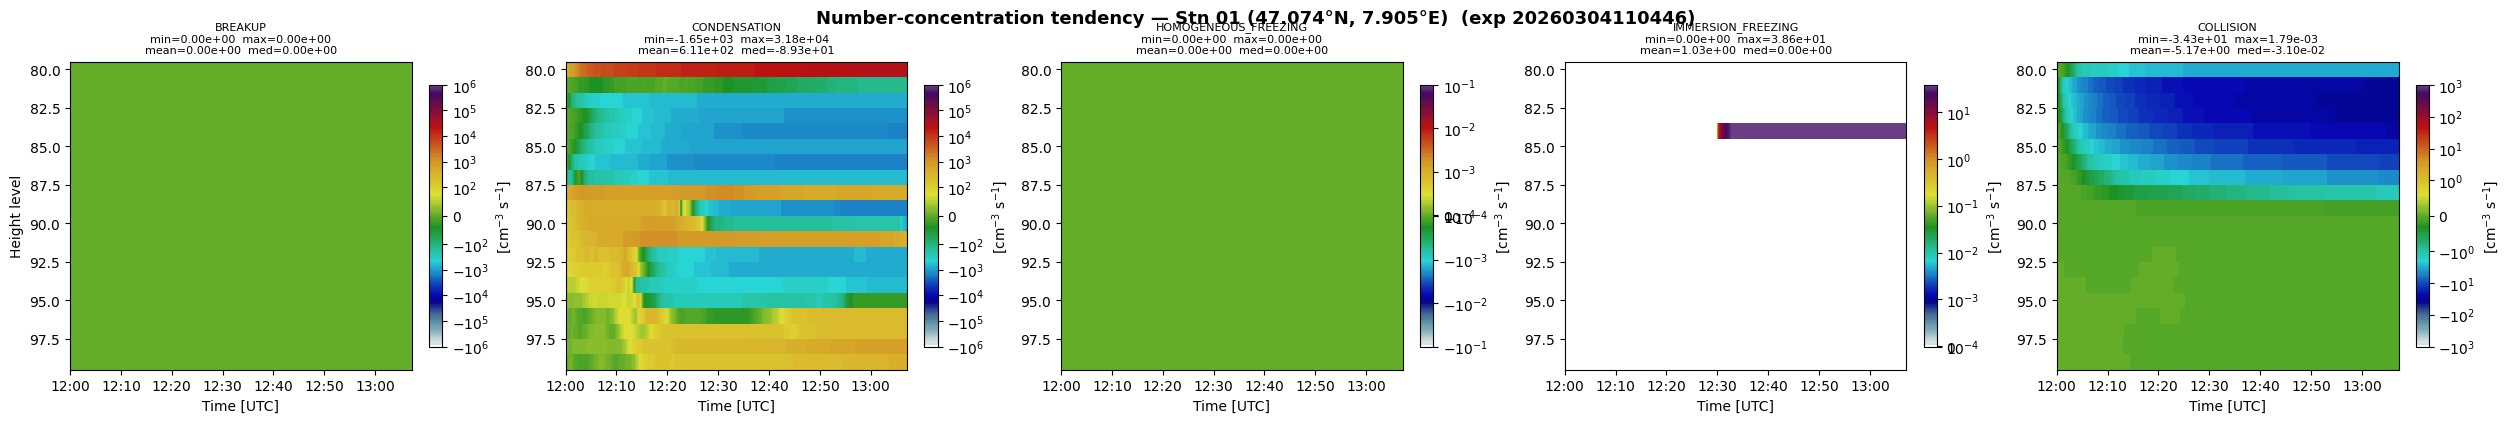

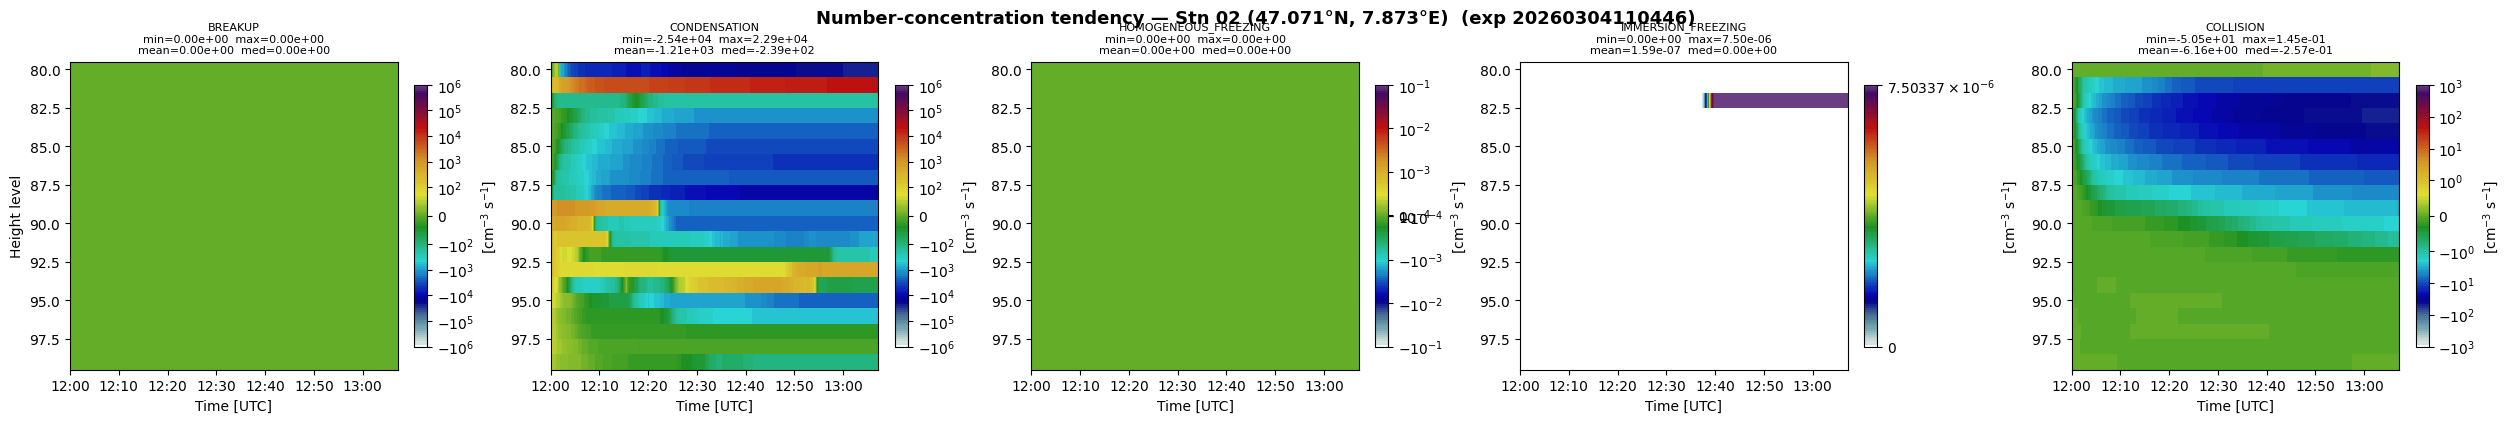

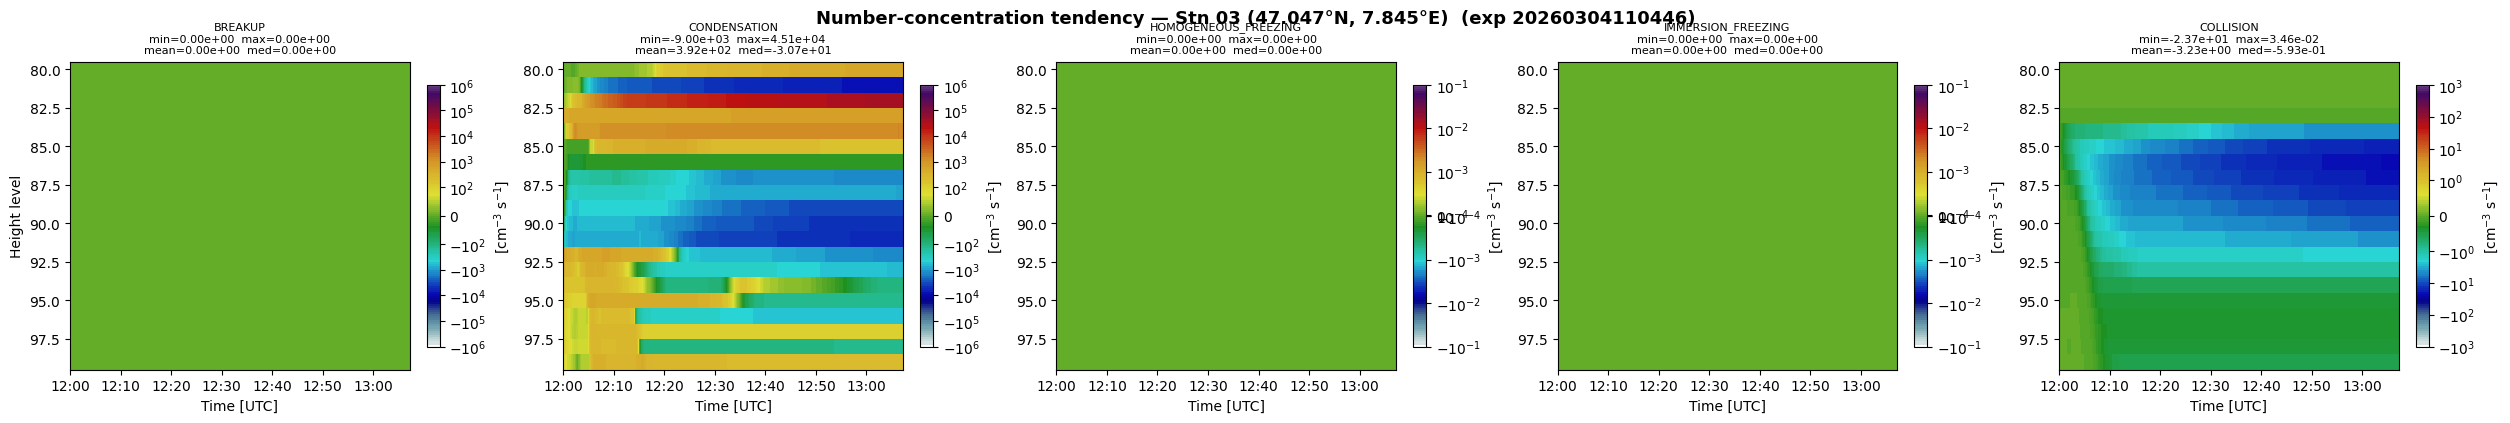

In [7]:
new_jet3 = create_new_jet3()
new_jet3_soft = create_fade_cmap(make_pastel(new_jet3, desaturation=0.25, darken=0.90), n_fade=2)

def get_norm_for_process(grp_name, kind="N"):
    """Build a SymLogNorm from metadata_config thresholds, falling back to defaults."""
    # find the first variable of this kind in the group to read linthresh/vlim
    members = process_groups.get(grp_name, [])
    for m in members:
        cfg = tendencies_cfg.get(grp_name, {}).get(m, {})
        if cfg:
            lt = cfg.get("linthresh", 1e-4)
            vlim = cfg.get("vlim", [-1, 1])
            return mcolors.SymLogNorm(linthresh=lt, linscale=1.0,
                                      vmin=vlim[0], vmax=vlim[1])
    return mcolors.SymLogNorm(linthresh=1e-4, linscale=0.01)


def plot_rates(rates_dict, unit_label, title_prefix):
    """Plot one figure per station, one column per process."""
    proc_names = list(rates_dict.keys())
    n_procs = len(proc_names)
    if n_procs == 0:
        print("No processes to plot.")
        return

    plot_kw = dict(x="time", y="height_level", cmap=new_jet3_soft,
                   add_colorbar=False, add_labels=False)
    kind = "N" if "number" in title_prefix.lower() or "N" in unit_label else "Q"

    for si in range(n_stations):
        slat = float(ds_exp.station_lat.values[si])
        slon = float(ds_exp.station_lon.values[si])
        sid  = int(ds_exp.station.values[si])
        stn_label = f"Stn {sid:02d} ({slat:.3f}°N, {slon:.3f}°E)"

        fig, axes = plt.subplots(1, n_procs,
                                 figsize=(n_procs * 5, 4),
                                 constrained_layout=True)
        if n_procs == 1:
            axes = [axes]

        for idx, proc in enumerate(proc_names):
            ax = axes[idx]
            da = rates_dict[proc].isel(station=si)
            norm = get_norm_for_process(proc, kind)
            pcm = da.plot.pcolormesh(ax=ax, norm=norm, **plot_kw)

            d = da.values.ravel()
            d = d[np.isfinite(d)]
            if d.size:
                stats = (f"min={d.min():.2e}  max={d.max():.2e}\n"
                         f"mean={d.mean():.2e}  med={np.median(d):.2e}")
            else:
                stats = "no finite data"
            ax.set_title(f"{proc}\n{stats}", fontsize=8)
            ax.invert_yaxis()
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
            ax.set_xlabel("Time [UTC]")
            if idx == 0:
                ax.set_ylabel("Height level")
            fig.colorbar(pcm, ax=ax, label=f"[{unit_label}]", shrink=0.85)

        fig.suptitle(f"{title_prefix} — {stn_label}  (exp {exp_label})",
                     fontsize=13, fontweight="bold", y=1.02)
        plt.show()


plot_rates(rates_N, unit_N, "Number-concentration tendency")

## Per-station process panels: mass-concentration tendencies

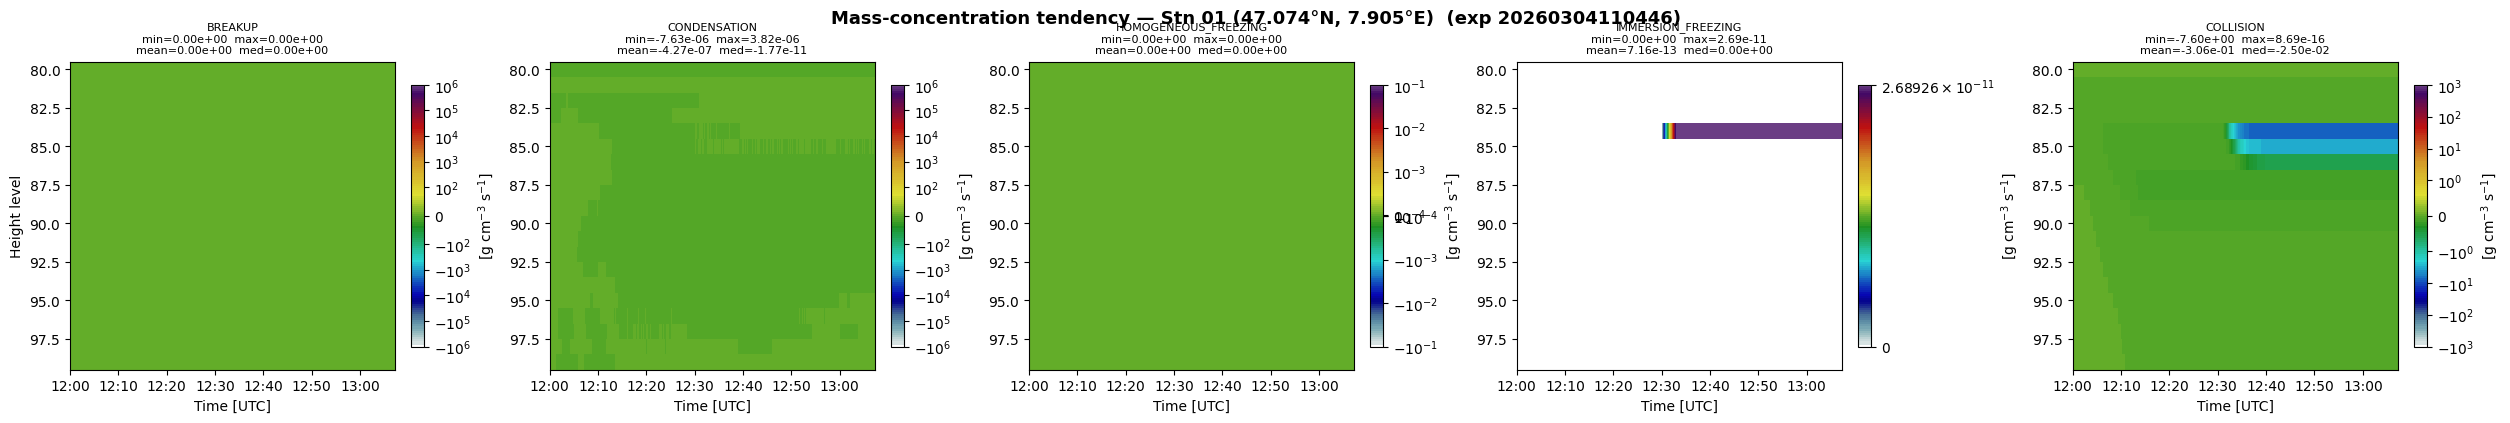

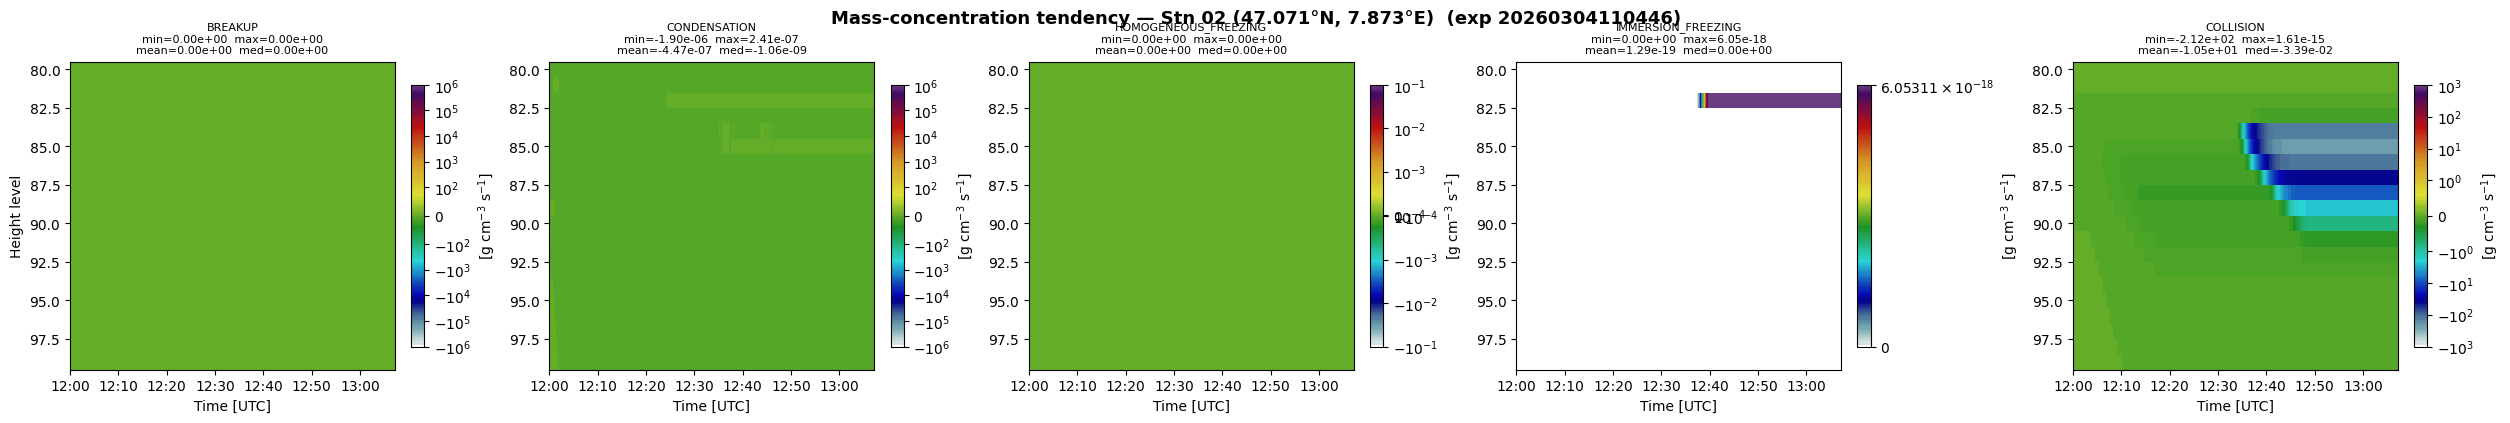

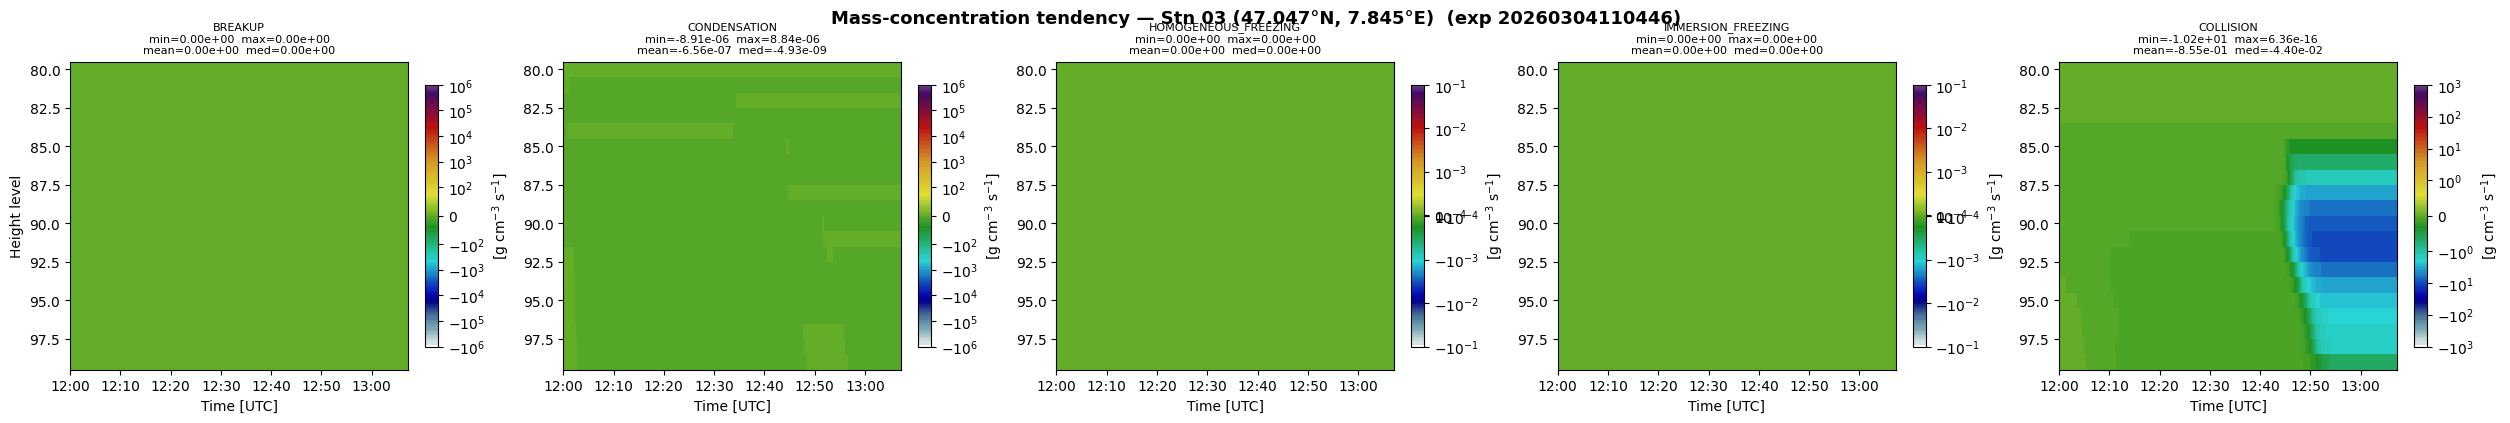

In [8]:
plot_rates(rates_Q, unit_Q, "Mass-concentration tendency")

## Dominant process identification

At each `(time, height)` cell, the process with the largest absolute
rate is chosen.  The categorical colour map shows which process
dominates the local budget.

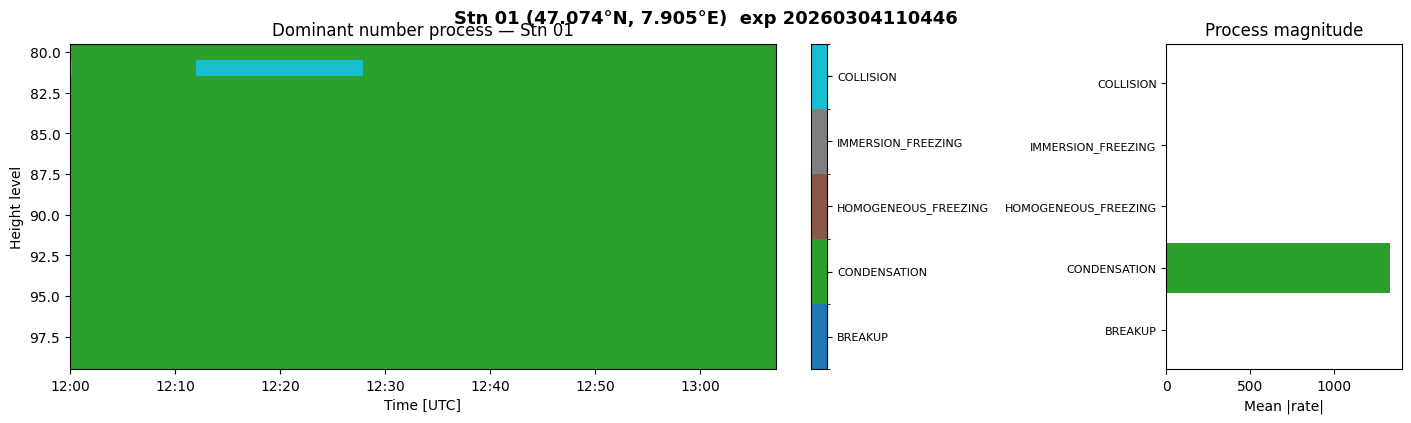

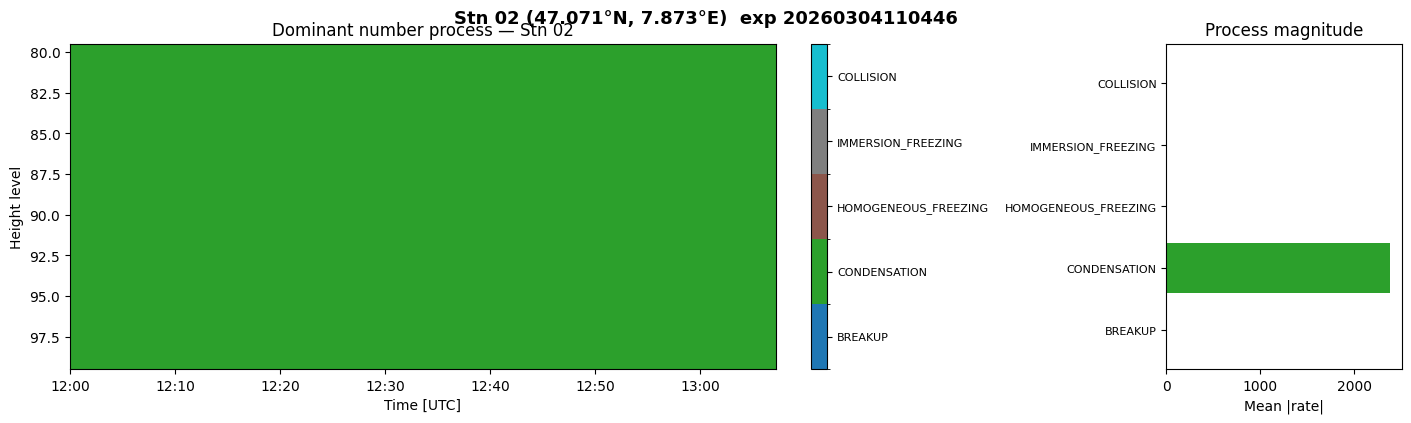

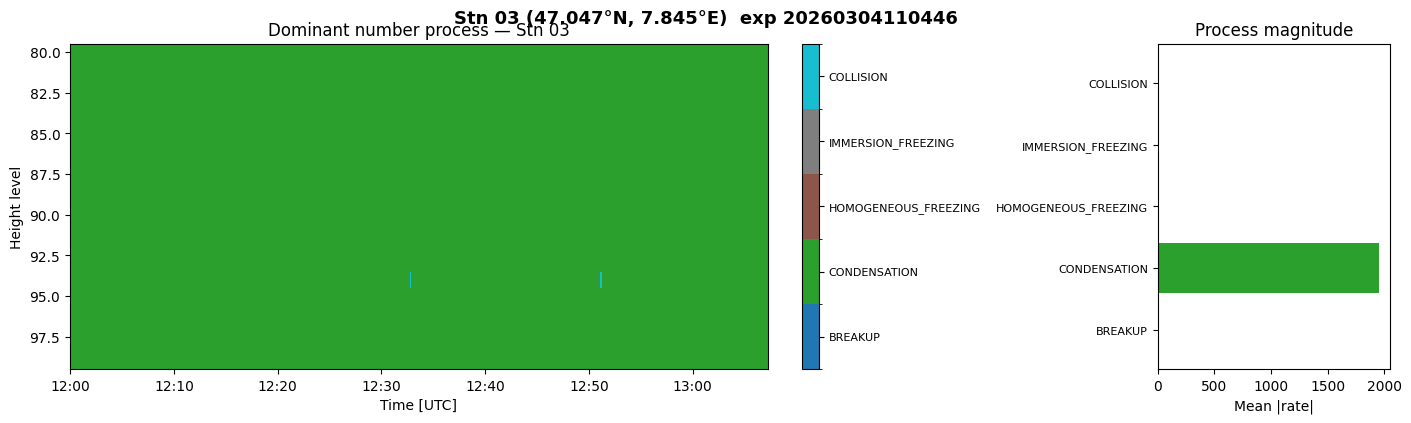

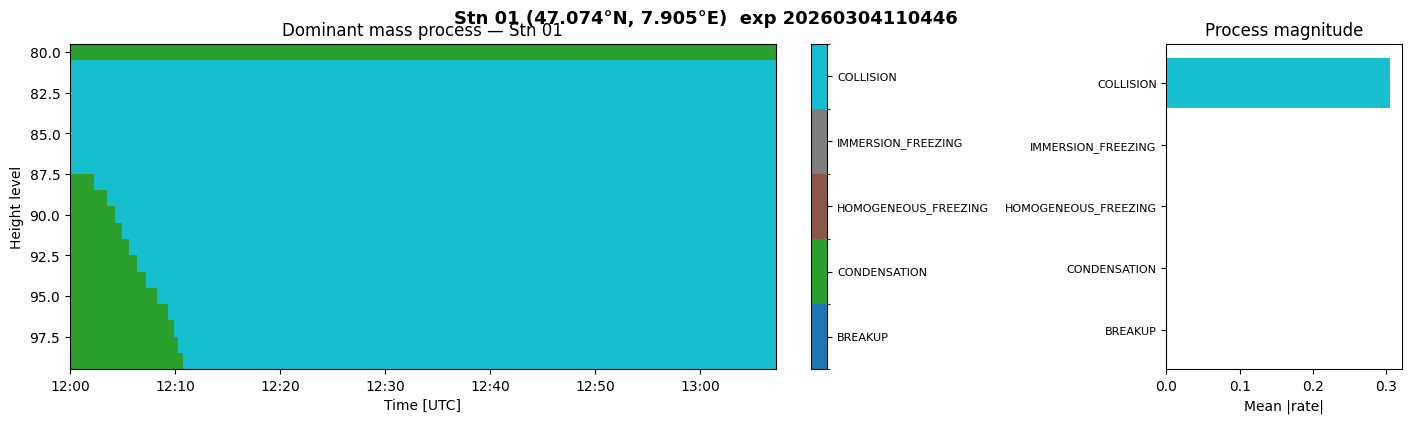

In [ ]:
def plot_dominant(rates_dict, kind_label):
    """Show categorical dominant-process map for each station."""
    proc_names = list(rates_dict.keys())
    n_procs = len(proc_names)
    if n_procs == 0:
        return

    colours = plt.cm.tab10(np.linspace(0, 1, max(n_procs, 3)))
    cmap_cat = mcolors.ListedColormap(colours[:n_procs])
    bounds = np.arange(n_procs + 1) - 0.5
    norm_cat = mcolors.BoundaryNorm(bounds, cmap_cat.N)

    for si in range(n_stations):
        sid = int(ds_exp.station.values[si])
        slat = float(ds_exp.station_lat.values[si])
        slon = float(ds_exp.station_lon.values[si])

        # stack absolute rates: (n_procs, time, height_level)
        abs_stack = np.stack([np.abs(rates_dict[p].isel(station=si).values)
                              for p in proc_names], axis=0)
        dominant_idx = np.nanargmax(abs_stack, axis=0).astype(float)
        # mask cells where ALL processes are NaN or zero
        all_zero = np.all(np.isnan(abs_stack) | (abs_stack == 0), axis=0)
        dominant_idx[all_zero] = np.nan

        fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True,
                                 gridspec_kw={"width_ratios": [3, 1]})

        # left: dominant process map
        ax = axes[0]
        time_vals = rates_dict[proc_names[0]].isel(station=si).coords["time"].values
        hl_vals   = rates_dict[proc_names[0]].isel(station=si).coords["height_level"].values
        pcm = ax.pcolormesh(time_vals, hl_vals, dominant_idx.T,
                            cmap=cmap_cat, norm=norm_cat, shading="auto")
        ax.invert_yaxis()
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax.set_xlabel("Time [UTC]")
        ax.set_ylabel("Height level")
        ax.set_title(f"Dominant {kind_label} process — Stn {sid:02d}")
        cbar = fig.colorbar(pcm, ax=ax, ticks=np.arange(n_procs))
        cbar.ax.set_yticklabels(proc_names, fontsize=8)

        # right: stacked bar of time-averaged absolute rate per process
        ax2 = axes[1]
        means = [float(np.nanmean(np.abs(rates_dict[p].isel(station=si).values)))
                 for p in proc_names]
        bars = ax2.barh(proc_names, means, color=colours[:n_procs])
        ax2.set_xlabel(f"Mean |rate|")
        ax2.set_title("Process magnitude")
        ax2.tick_params(axis="y", labelsize=8)

        fig.suptitle(f"Stn {sid:02d} ({slat:.3f}°N, {slon:.3f}°E)  exp {exp_label}",
                     fontsize=13, fontweight="bold", y=1.02)
        plt.show()


plot_dominant(rates_N, "number")
plot_dominant(rates_Q, "mass")

## Net / positive / negative tendency decomposition

For the key processes, split into positive (source) and negative (sink)
contributions to see growth vs. loss separately.

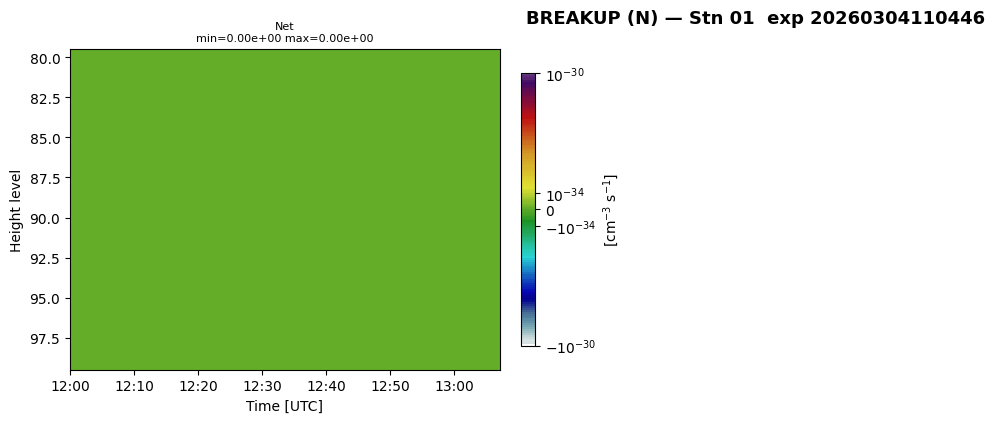

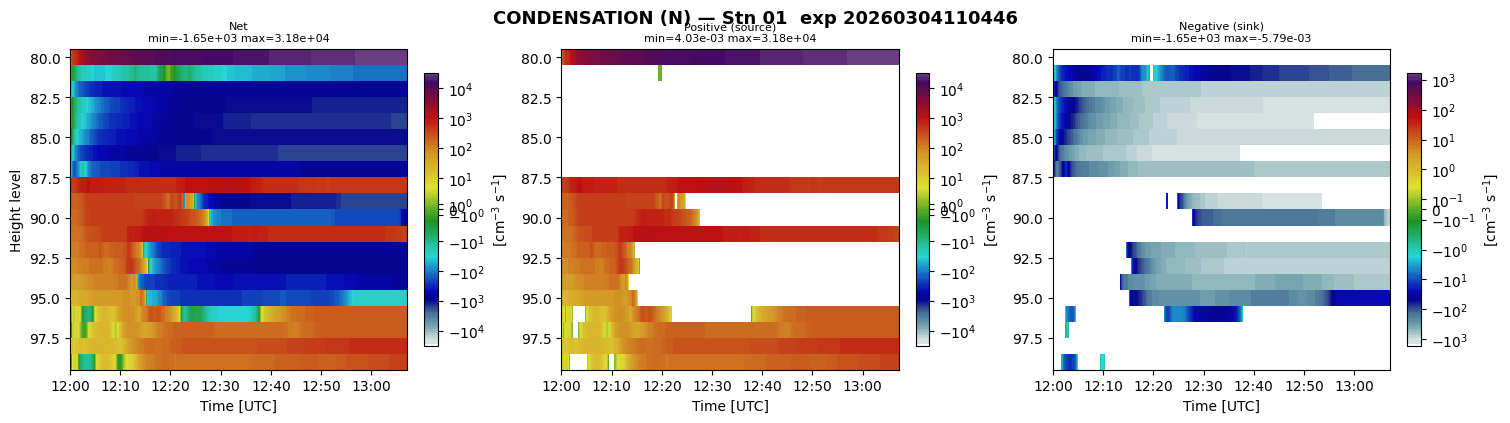

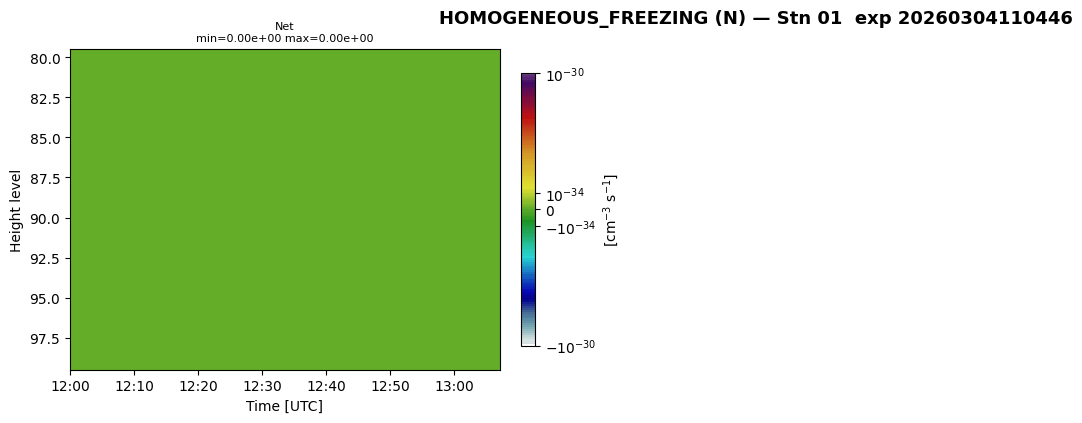

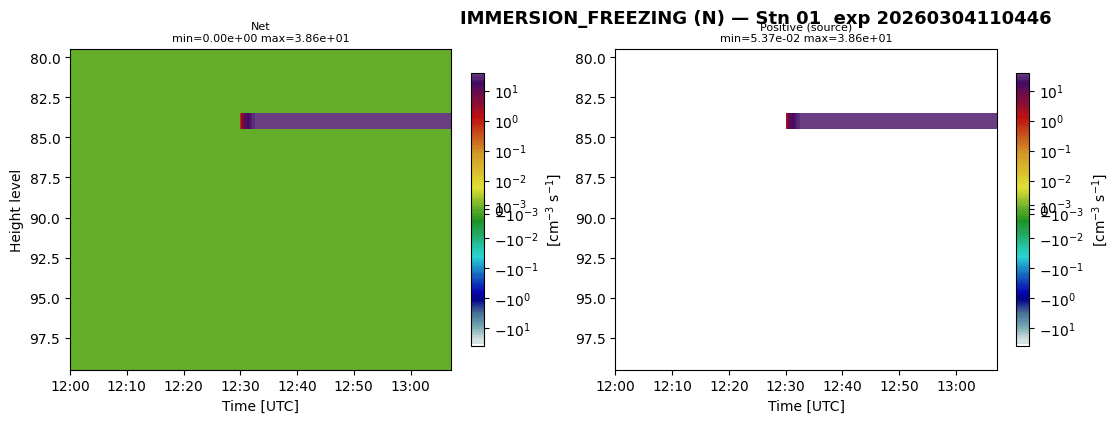

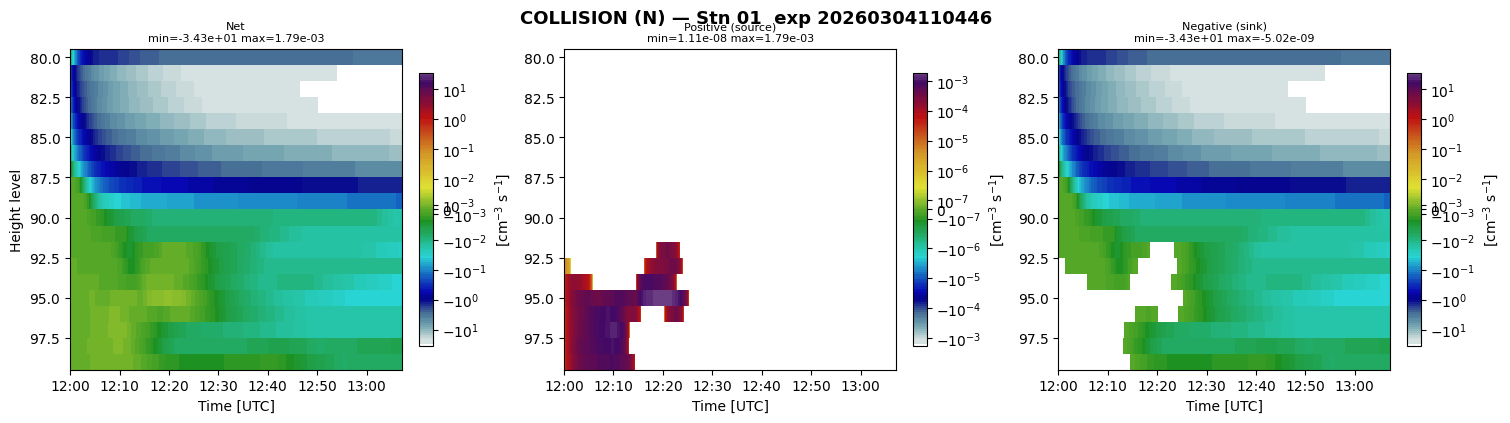

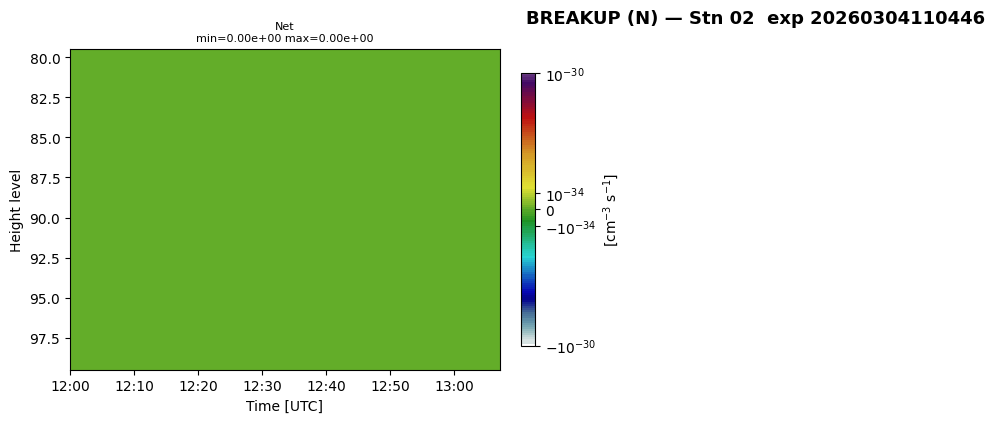

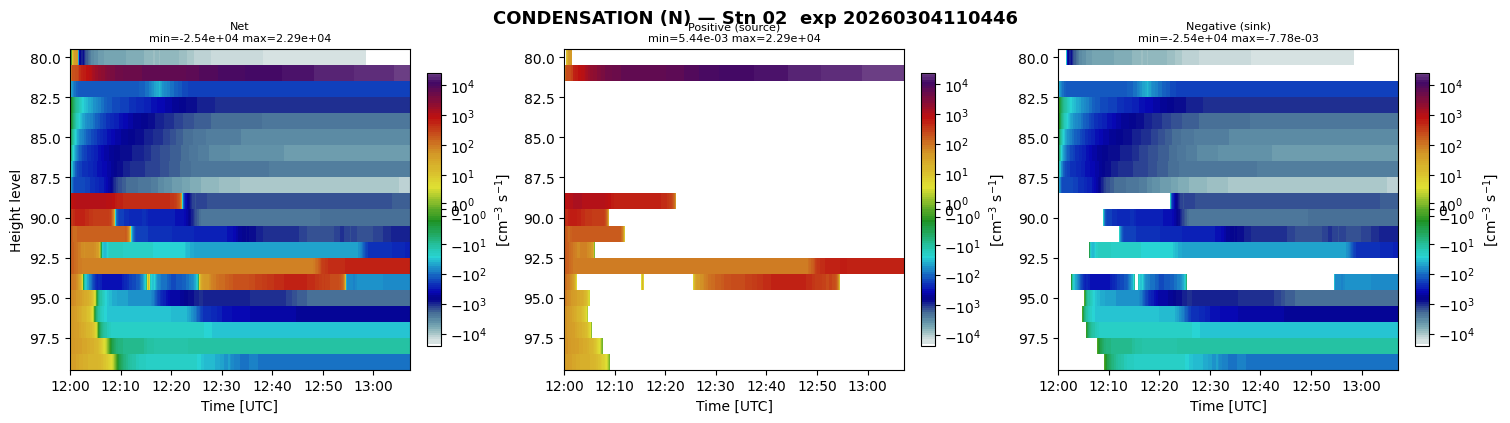

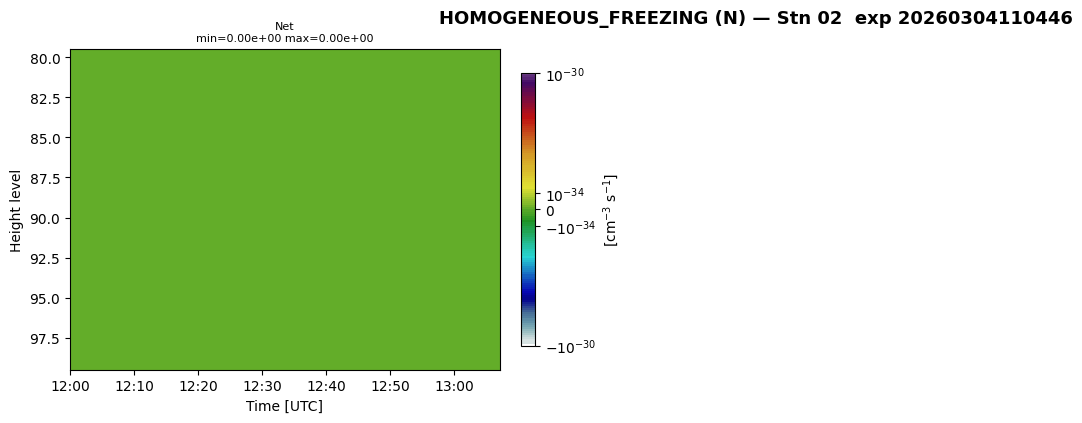

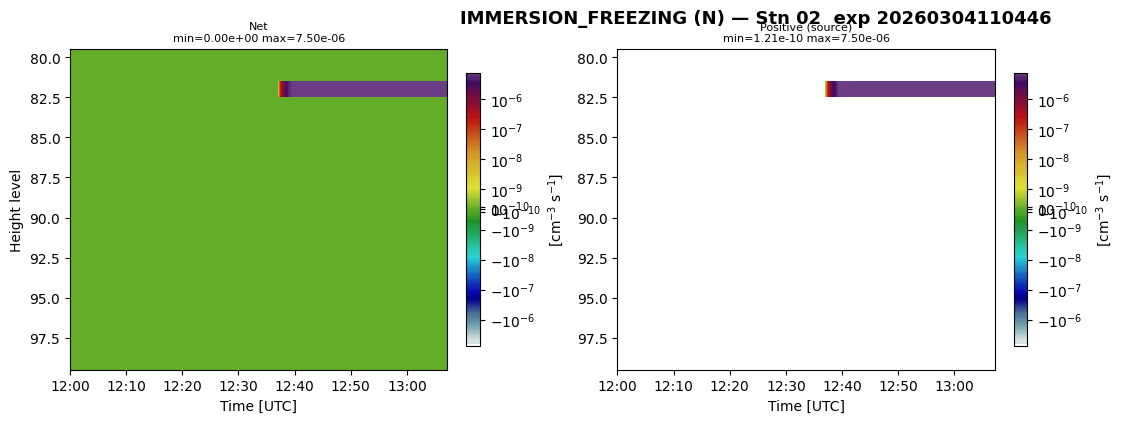

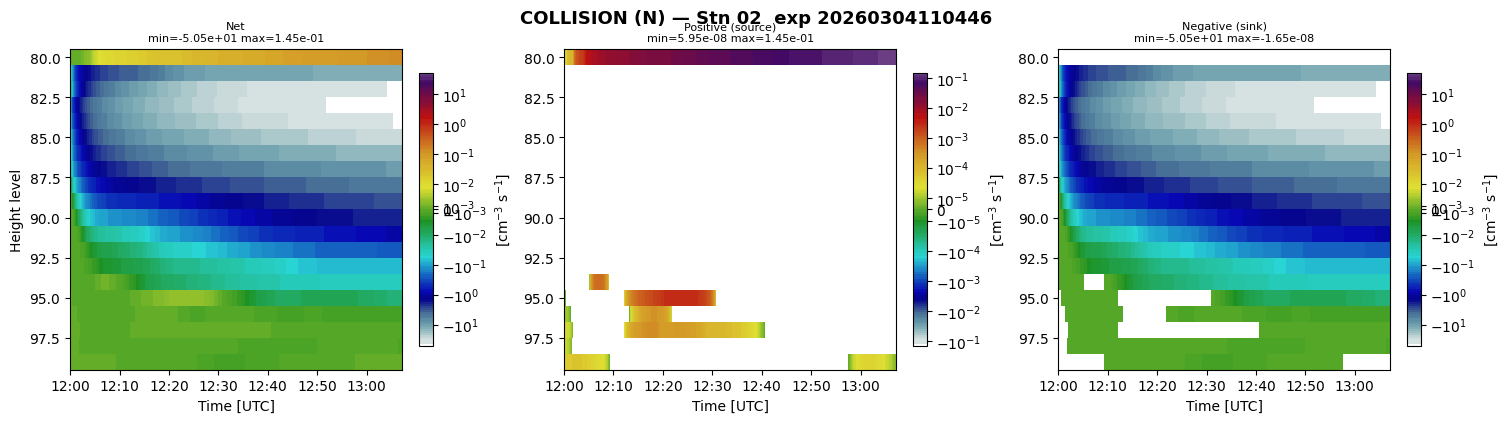

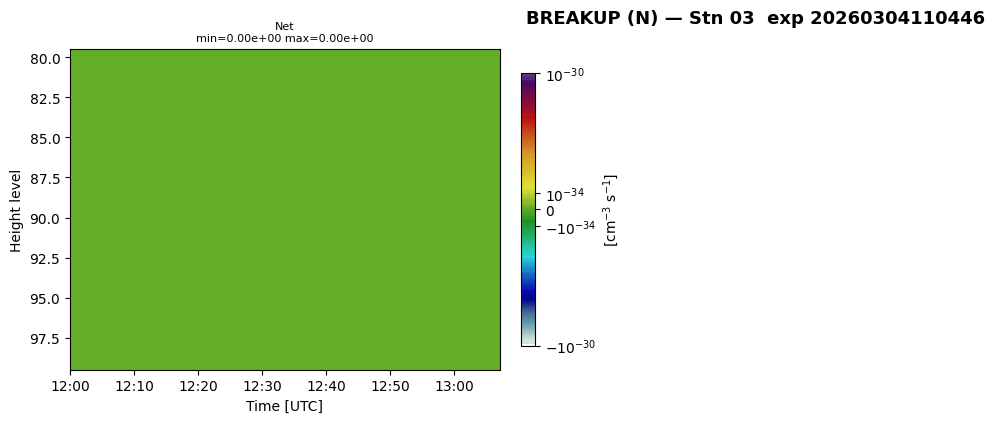

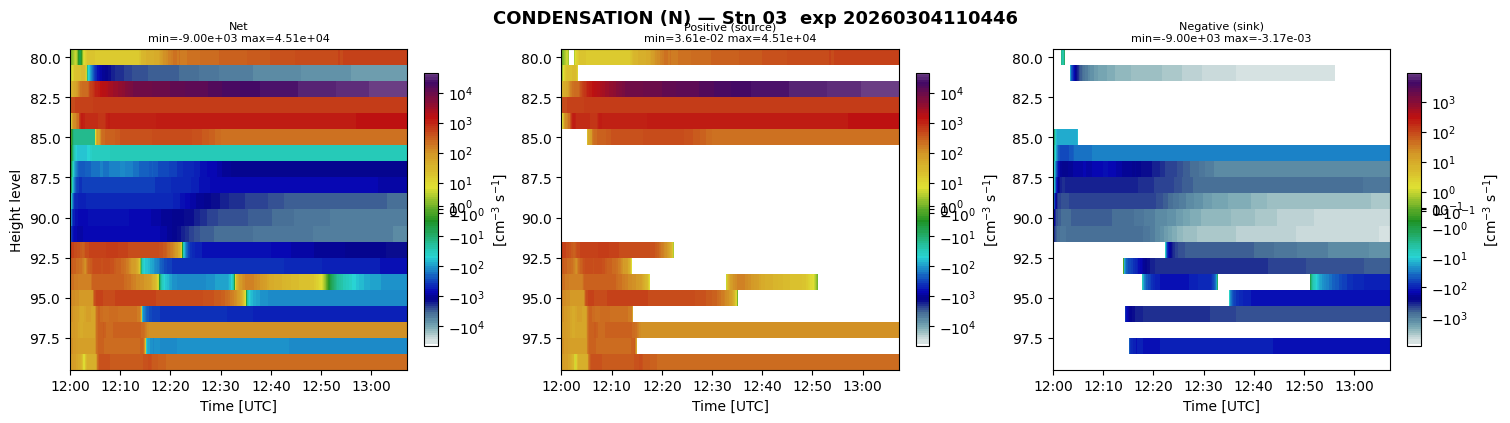

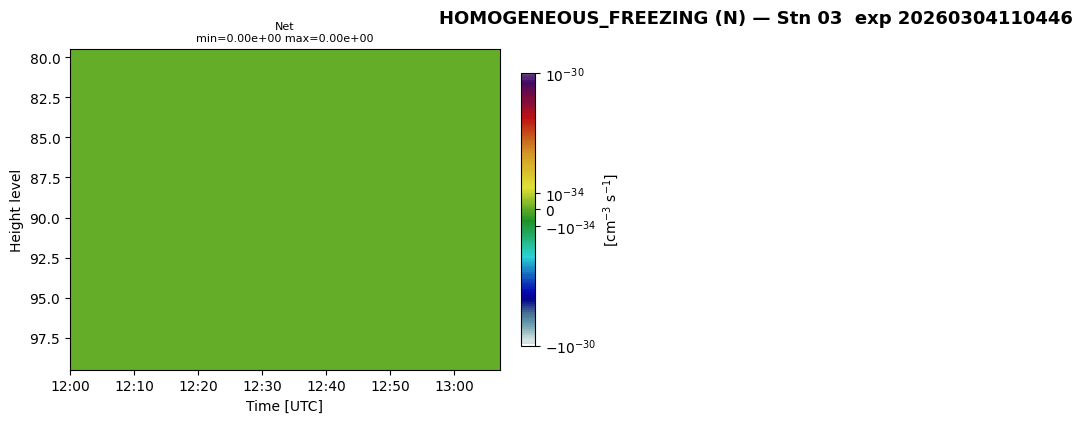

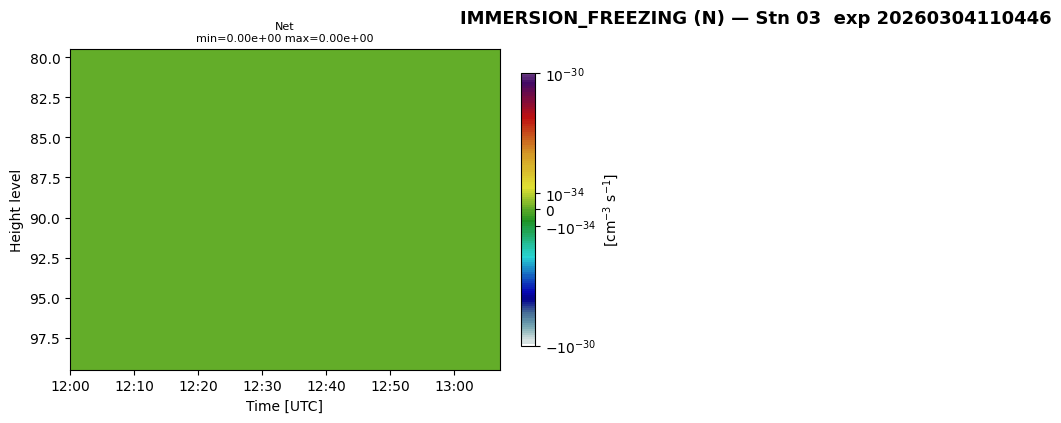

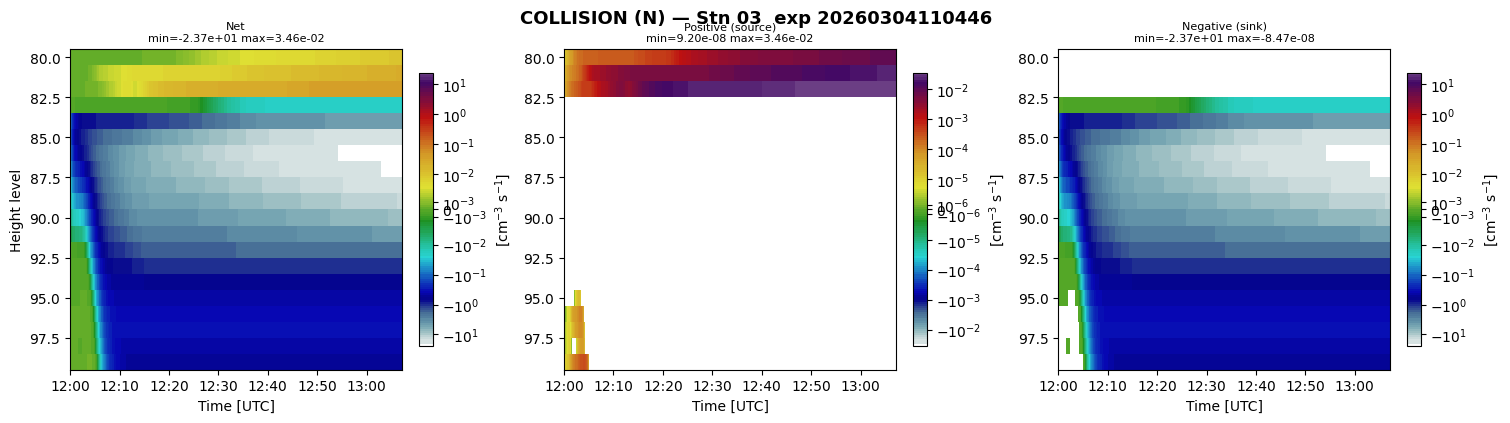

In [ ]:
plot_kw = dict(x="time", y="height_level", cmap=new_jet3_soft,
               add_colorbar=False, add_labels=False)

for si in range(n_stations):
    sid = int(ds_exp.station.values[si])
    slat = float(ds_exp.station_lat.values[si])
    slon = float(ds_exp.station_lon.values[si])

    for grp, rate_da in rates_N.items():
        da = rate_da.isel(station=si)
        da_pos = xr.where(da > 0, da, np.nan)
        da_neg = xr.where(da < 0, da, np.nan)

        fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
        titles = ["Net", "Positive (source)", "Negative (sink)"]
        datas  = [da, da_pos, da_neg]
        for idx, (ttl, dd) in enumerate(zip(titles, datas)):
            ax = axes[idx]
            d = dd.values.ravel()
            d = d[np.isfinite(d)]
            if d.size == 0:
                ax.set_title(f"{ttl}: no data", fontsize=9)
                ax.set_visible(False)
                continue
            vabs = max(abs(np.nanmin(d)), abs(np.nanmax(d)), 1e-30)
            norm = mcolors.SymLogNorm(linthresh=vabs * 1e-4, linscale=0.5,
                                      vmin=-vabs, vmax=vabs)
            pcm = dd.plot.pcolormesh(ax=ax, norm=norm, **plot_kw)
            ax.invert_yaxis()
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
            ax.set_xlabel("Time [UTC]")
            if idx == 0:
                ax.set_ylabel("Height level")
            stats = f"min={d.min():.2e} max={d.max():.2e}"
            ax.set_title(f"{ttl}\n{stats}", fontsize=8)
            fig.colorbar(pcm, ax=ax, label=f"[{unit_N}]", shrink=0.85)

        fig.suptitle(f"{grp} (N) — Stn {sid:02d}  exp {exp_label}",
                     fontsize=13, fontweight="bold", y=1.02)
        plt.show()